### This file contains code for baseline GNNs

In [ ]:
from torch_geometric.loader import DataLoader
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_add_pool, global_mean_pool
from sklearn.metrics import roc_auc_score
import numpy as np
from torch_geometric.nn import AttentiveFP

import sys
import os
sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath(''))))
from loadBBBP import train_set, val_set, test_set, dataset

/var/folders/86/621cyyk16gd11mlx6jm2h4c80000gn/T/ipykernel_87555/1920596255.py:10: DeprecationWarning: loadBBBP.py is no longer used. Please use loadMoleculeData.py instead.
  from loadBBBP import train_set, val_set, test_set, dataset
[17:40:44] WARNING: not removing hydrogen atom without neighbors
[17:40:44] WARNING: not removing hydrogen atom without neighbors
[17:40:44] WARNING: not removing hydrogen atom without neighbors
[17:40:44] WARNING: not removing hydrogen atom without neighbors
[17:40:44] WARNING: not removing hydrogen atom without neighbors
[17:40:44] WARNING: not removing hydrogen atom without neighbors
[17:40:44] WARNING: not removing hydrogen atom without neighbors
[17:40:44] WARNING: not removing hydrogen atom without neighbors
[17:40:44] WARNING: not removing hydrogen atom without neighbors
[17:40:44] WARNING: not removing hydrogen atom without neighbors
[17:40:44] WARNING: not removing hydrogen atom without neighbors
[17:40:44] WARNING: not removing hydrogen atom wit

In [5]:
batch_size = 256
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_set,  batch_size=batch_size, shuffle=False)


In [3]:
class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels=128, num_layers=3, dropout=0.2):
        super().__init__()
        self.convs = nn.ModuleList()
        self.convs.append(GCNConv(in_channels, hidden_channels))
        for _ in range(num_layers-2):
            self.convs.append(GCNConv(hidden_channels, hidden_channels))
        self.convs.append(GCNConv(hidden_channels, hidden_channels))

        self.dropout = dropout
        self.lin = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels),
            nn.ReLU(),
            nn.Dropout(self.dropout),
            nn.Linear(hidden_channels, 1)
        )

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = x.float()
        for conv in self.convs:
            x = conv(x, edge_index)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
            g = global_mean_pool(x, batch)

        return self.lin(g).view(-1)

In [4]:
from torch_geometric.nn import GINEConv
class GINE(torch.nn.Module):
    def __init__(self, in_channels, edge_dim, hidden=128, layers=3):
        super().__init__()
        def mlp():
            return nn.Sequential(nn.Linear(in_channels if _==0 else hidden, hidden),
                                 nn.ReLU(), nn.Linear(hidden, hidden))
        self.convs = nn.ModuleList()
        for _ in range(layers):
            self.convs.append(GINEConv(mlp(), edge_dim=edge_dim))
        self.lin = nn.Linear(hidden, 1)
    def forward(self, data):
        x, edge_index, edge_attr, batch = data.x, data.edge_index, data.edge_attr, data.batch
        x = x.float()
        edge_attr = edge_attr.float()
        for conv in self.convs:
            x = conv(x, edge_index, edge_attr)
            x = F.relu(x)
        g = global_mean_pool(x, batch)
        return self.lin(g).view(-1)




In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = GCN(in_channels=dataset.num_features, hidden_channels=128, num_layers=3).to(device)
# model = GINE(in_channels=dataset.num_features, edge_dim=dataset[0].edge_attr.size(-1)).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
criterion = nn.BCEWithLogitsLoss()

def do_epoch(loader, training: bool, model):
    if training:
        model.train()
    else:
        model.eval()

    all_logits, all_labels, total_loss, n = [], [], 0.0, 0
    for batch in loader:
        batch = batch.to(device)
        logits = model(batch)
        
        logits = logits.view(-1)
        labels = batch.y.view(-1).float() 
        loss = criterion(logits, labels)

        if training:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * labels.size(0)
        n += labels.size(0)
        all_logits.append(logits.detach().cpu())
        all_labels.append(labels.detach().cpu())

    all_logits = torch.cat(all_logits).numpy()
    all_labels = torch.cat(all_labels).numpy()

    # Some splits can be all-one or all-zero; handle safely for ROC-AUC
    try:
        auc = roc_auc_score(all_labels, 1/(1+np.exp(-all_logits)))
    except ValueError:
        auc = float("nan")
    return total_loss / n, auc

best_val_auc, best_test_auc = -1, -1
epochs = 100
for epoch in range(1, epochs+1):
    train_loss, train_auc = do_epoch(train_loader, training=True, model=model)
    val_loss,   val_auc   = do_epoch(val_loader,   training=False, model=model)
    test_loss,  test_auc  = do_epoch(test_loader,  training=False, model=model)

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save(model.state_dict(), "baselineGINE.pt")

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:02d} | "
              f"Train loss {train_loss:.4f} AUC {train_auc:.3f} | "
              f"Val AUC {val_auc:.3f}")

print(f"\nBest Val AUC: {best_val_auc:.3f}")

ckpt = torch.load("baselineGINE.pt", map_location=device)
model.load_state_dict(ckpt)
_, test_auc = do_epoch(test_loader, training=False, model=model)
print(f"Test AUC (best-val checkpoint): {test_auc:.3f}")
 
# TODO: Address test val AUC gap
# Issue with scaffold split? Seems unlikely
# Issue with training? switch to cross-validation with scaffold-based splits?

Epoch 01 | Train loss 0.5557 AUC 0.478 | Val AUC 0.596
Epoch 05 | Train loss 0.4683 AUC 0.541 | Val AUC 0.871
Epoch 10 | Train loss 0.4507 AUC 0.683 | Val AUC 0.866
Epoch 15 | Train loss 0.4257 AUC 0.724 | Val AUC 0.862
Epoch 20 | Train loss 0.4108 AUC 0.747 | Val AUC 0.863
Epoch 25 | Train loss 0.4028 AUC 0.760 | Val AUC 0.872
Epoch 30 | Train loss 0.3958 AUC 0.771 | Val AUC 0.879
Epoch 35 | Train loss 0.3884 AUC 0.785 | Val AUC 0.884
Epoch 40 | Train loss 0.3871 AUC 0.786 | Val AUC 0.887
Epoch 45 | Train loss 0.3941 AUC 0.771 | Val AUC 0.894
Epoch 50 | Train loss 0.3770 AUC 0.799 | Val AUC 0.893
Epoch 55 | Train loss 0.3922 AUC 0.771 | Val AUC 0.902
Epoch 60 | Train loss 0.3714 AUC 0.802 | Val AUC 0.903
Epoch 65 | Train loss 0.3717 AUC 0.806 | Val AUC 0.903
Epoch 70 | Train loss 0.3638 AUC 0.811 | Val AUC 0.907
Epoch 75 | Train loss 0.3717 AUC 0.805 | Val AUC 0.912
Epoch 80 | Train loss 0.3528 AUC 0.825 | Val AUC 0.909
Epoch 85 | Train loss 0.3589 AUC 0.815 | Val AUC 0.908
Epoch 90 |

In [ ]:
param_grid = {
    'hidden_channels': [64, 128, 256],
    'num_layers': [2, 3, 4, 5],
    'dropout': [0.1],
    'learning_rate': [1e-2, 1e-3],
    'weight_decay': [1e-5, 1e-7]
}

In [8]:
import itertools, json, time
from copy import deepcopy

# Reuse loaders and dataset from previous cells

def train_one_config(config, max_epochs=60, patience=10, device=torch.device("cuda" if torch.cuda.is_available() else "cpu")):
    model = GCN(
        in_channels=dataset.num_features,
        hidden_channels=config['hidden_channels'],
        num_layers=config['num_layers'],
        dropout=config['dropout']
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(), lr=config['learning_rate'], weight_decay=config['weight_decay']
    )
    criterion = nn.BCEWithLogitsLoss()

    def do_epoch(loader, training: bool):
        if training:
            model.train()
        else:
            model.eval()
        all_logits, all_labels, total_loss, n = [], [], 0.0, 0
        for batch in loader:
            batch = batch.to(device)
            logits = model(batch).view(-1)
            labels = batch.y.view(-1).float()
            loss = criterion(logits, labels)
            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * labels.size(0)
            n += labels.size(0)
            all_logits.append(logits.detach().cpu())
            all_labels.append(labels.detach().cpu())
        all_logits = torch.cat(all_logits).numpy()
        all_labels = torch.cat(all_labels).numpy()
        try:
            auc = roc_auc_score(all_labels, 1/(1+np.exp(-all_logits)))
        except ValueError:
            auc = float("nan")
        return total_loss / n, auc

    best_val_auc = -1.0
    best_state = None
    best_epoch = -1
    epochs_without_improvement = 0
    
    # Track epoch-by-epoch data for plotting
    epoch_data = {
        'epochs': [],
        'train_losses': [],
        'val_losses': [],
        'train_aucs': [],
        'val_aucs': []
    }

    for epoch in range(1, max_epochs+1):
        train_loss, train_auc = do_epoch(train_loader, training=True)
        val_loss,   val_auc   = do_epoch(val_loader,   training=False)
        
        # Store data every 10 epochs or at epoch 1
        if epoch % 10 == 0 or epoch == 1:
            epoch_data['epochs'].append(epoch)
            epoch_data['train_losses'].append(float(train_loss))
            epoch_data['val_losses'].append(float(val_loss))
            epoch_data['train_aucs'].append(float(train_auc))
            epoch_data['val_aucs'].append(float(val_auc))
        
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_state = deepcopy(model.state_dict())
            best_epoch = epoch
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
        if epochs_without_improvement >= patience:
            break
    
    # Load best state and compute test AUC
    model.load_state_dict(best_state)
    _, test_auc = do_epoch(test_loader, training=False)
    return {
        'best_val_auc': float(best_val_auc),
        'best_epoch': int(best_epoch),
        'test_auc_at_best': float(test_auc),
        'state_dict': best_state,
        'epoch_data': epoch_data
    }


# Grid search
keys = list(param_grid.keys())
all_results = []
all_epoch_data = []  # Store epoch-by-epoch data for plotting
best_overall = None
best_auc = -1.0
start_time = time.time()

for values in itertools.product(*(param_grid[k] for k in keys)):
    cfg = {k: v for k, v in zip(keys, values)}
    print(f"\nConfig: {cfg}")
    result = train_one_config(cfg, max_epochs=80, patience=12)
    rec = {**cfg, 'best_val_auc': result['best_val_auc'], 'best_epoch': result['best_epoch'], 'test_auc_at_best': result['test_auc_at_best']}
    all_results.append(rec)
    
    # Store epoch data for plotting
    epoch_data = result['epoch_data']
    epoch_data['config'] = cfg  # Add config info to epoch data
    all_epoch_data.append(epoch_data)
    
    if result['best_val_auc'] > best_auc:
        best_auc = result['best_val_auc']
        best_overall = {'config': cfg, **result}
        torch.save(result['state_dict'], 'best_gcn_grid.pt')
        print(f"New best AUC: {best_auc:.4f} with cfg={cfg}")

# Persist results
with open('grid_results.json', 'w') as f:
    json.dump(all_results, f, indent=2)

# Save epoch data for plotting
with open('grid_epoch_data.json', 'w') as f:
    json.dump(all_epoch_data, f, indent=2)

import pandas as pd
pd.DataFrame(all_results).to_csv('grid_results.csv', index=False)

# Create a DataFrame for epoch data (useful for plotting)
epoch_df_data = []
for model_data in all_epoch_data:
    config = model_data['config']
    for i, epoch in enumerate(model_data['epochs']):
        epoch_df_data.append({
            'hidden_channels': config['hidden_channels'],
            'num_layers': config['num_layers'],
            'dropout': config['dropout'],
            'learning_rate': config['learning_rate'],
            'weight_decay': config['weight_decay'],
            'epoch': epoch,
            'train_loss': model_data['train_losses'][i],
            'val_loss': model_data['val_losses'][i],
            'train_auc': model_data['train_aucs'][i],
            'val_auc': model_data['val_aucs'][i]
        })

epoch_df = pd.DataFrame(epoch_df_data)
epoch_df.to_csv('grid_epoch_data.csv', index=False)

print(f"\nBest config: {best_overall['config']} | Val AUC {best_overall['best_val_auc']:.4f} | Test AUC {best_overall['test_auc_at_best']:.4f}")
print(f"Total time: {time.time() - start_time:.1f}s for {len(all_results)} runs")
print(f"Epoch data saved to 'grid_epoch_data.csv' for plotting")



Config: {'hidden_channels': 64, 'num_layers': 2, 'dropout': 0.1, 'learning_rate': 0.01, 'weight_decay': 1e-05}
New best AUC: 0.8668 with cfg={'hidden_channels': 64, 'num_layers': 2, 'dropout': 0.1, 'learning_rate': 0.01, 'weight_decay': 1e-05}

Config: {'hidden_channels': 64, 'num_layers': 2, 'dropout': 0.1, 'learning_rate': 0.01, 'weight_decay': 1e-06}

Config: {'hidden_channels': 64, 'num_layers': 2, 'dropout': 0.1, 'learning_rate': 0.01, 'weight_decay': 1e-07}
New best AUC: 0.8690 with cfg={'hidden_channels': 64, 'num_layers': 2, 'dropout': 0.1, 'learning_rate': 0.01, 'weight_decay': 1e-07}

Config: {'hidden_channels': 64, 'num_layers': 2, 'dropout': 0.1, 'learning_rate': 0.001, 'weight_decay': 1e-05}

Config: {'hidden_channels': 64, 'num_layers': 2, 'dropout': 0.1, 'learning_rate': 0.001, 'weight_decay': 1e-06}
New best AUC: 0.8889 with cfg={'hidden_channels': 64, 'num_layers': 2, 'dropout': 0.1, 'learning_rate': 0.001, 'weight_decay': 1e-06}

Config: {'hidden_channels': 64, 'num_

/var/folders/86/621cyyk16gd11mlx6jm2h4c80000gn/T/ipykernel_63051/3341766731.py:27: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


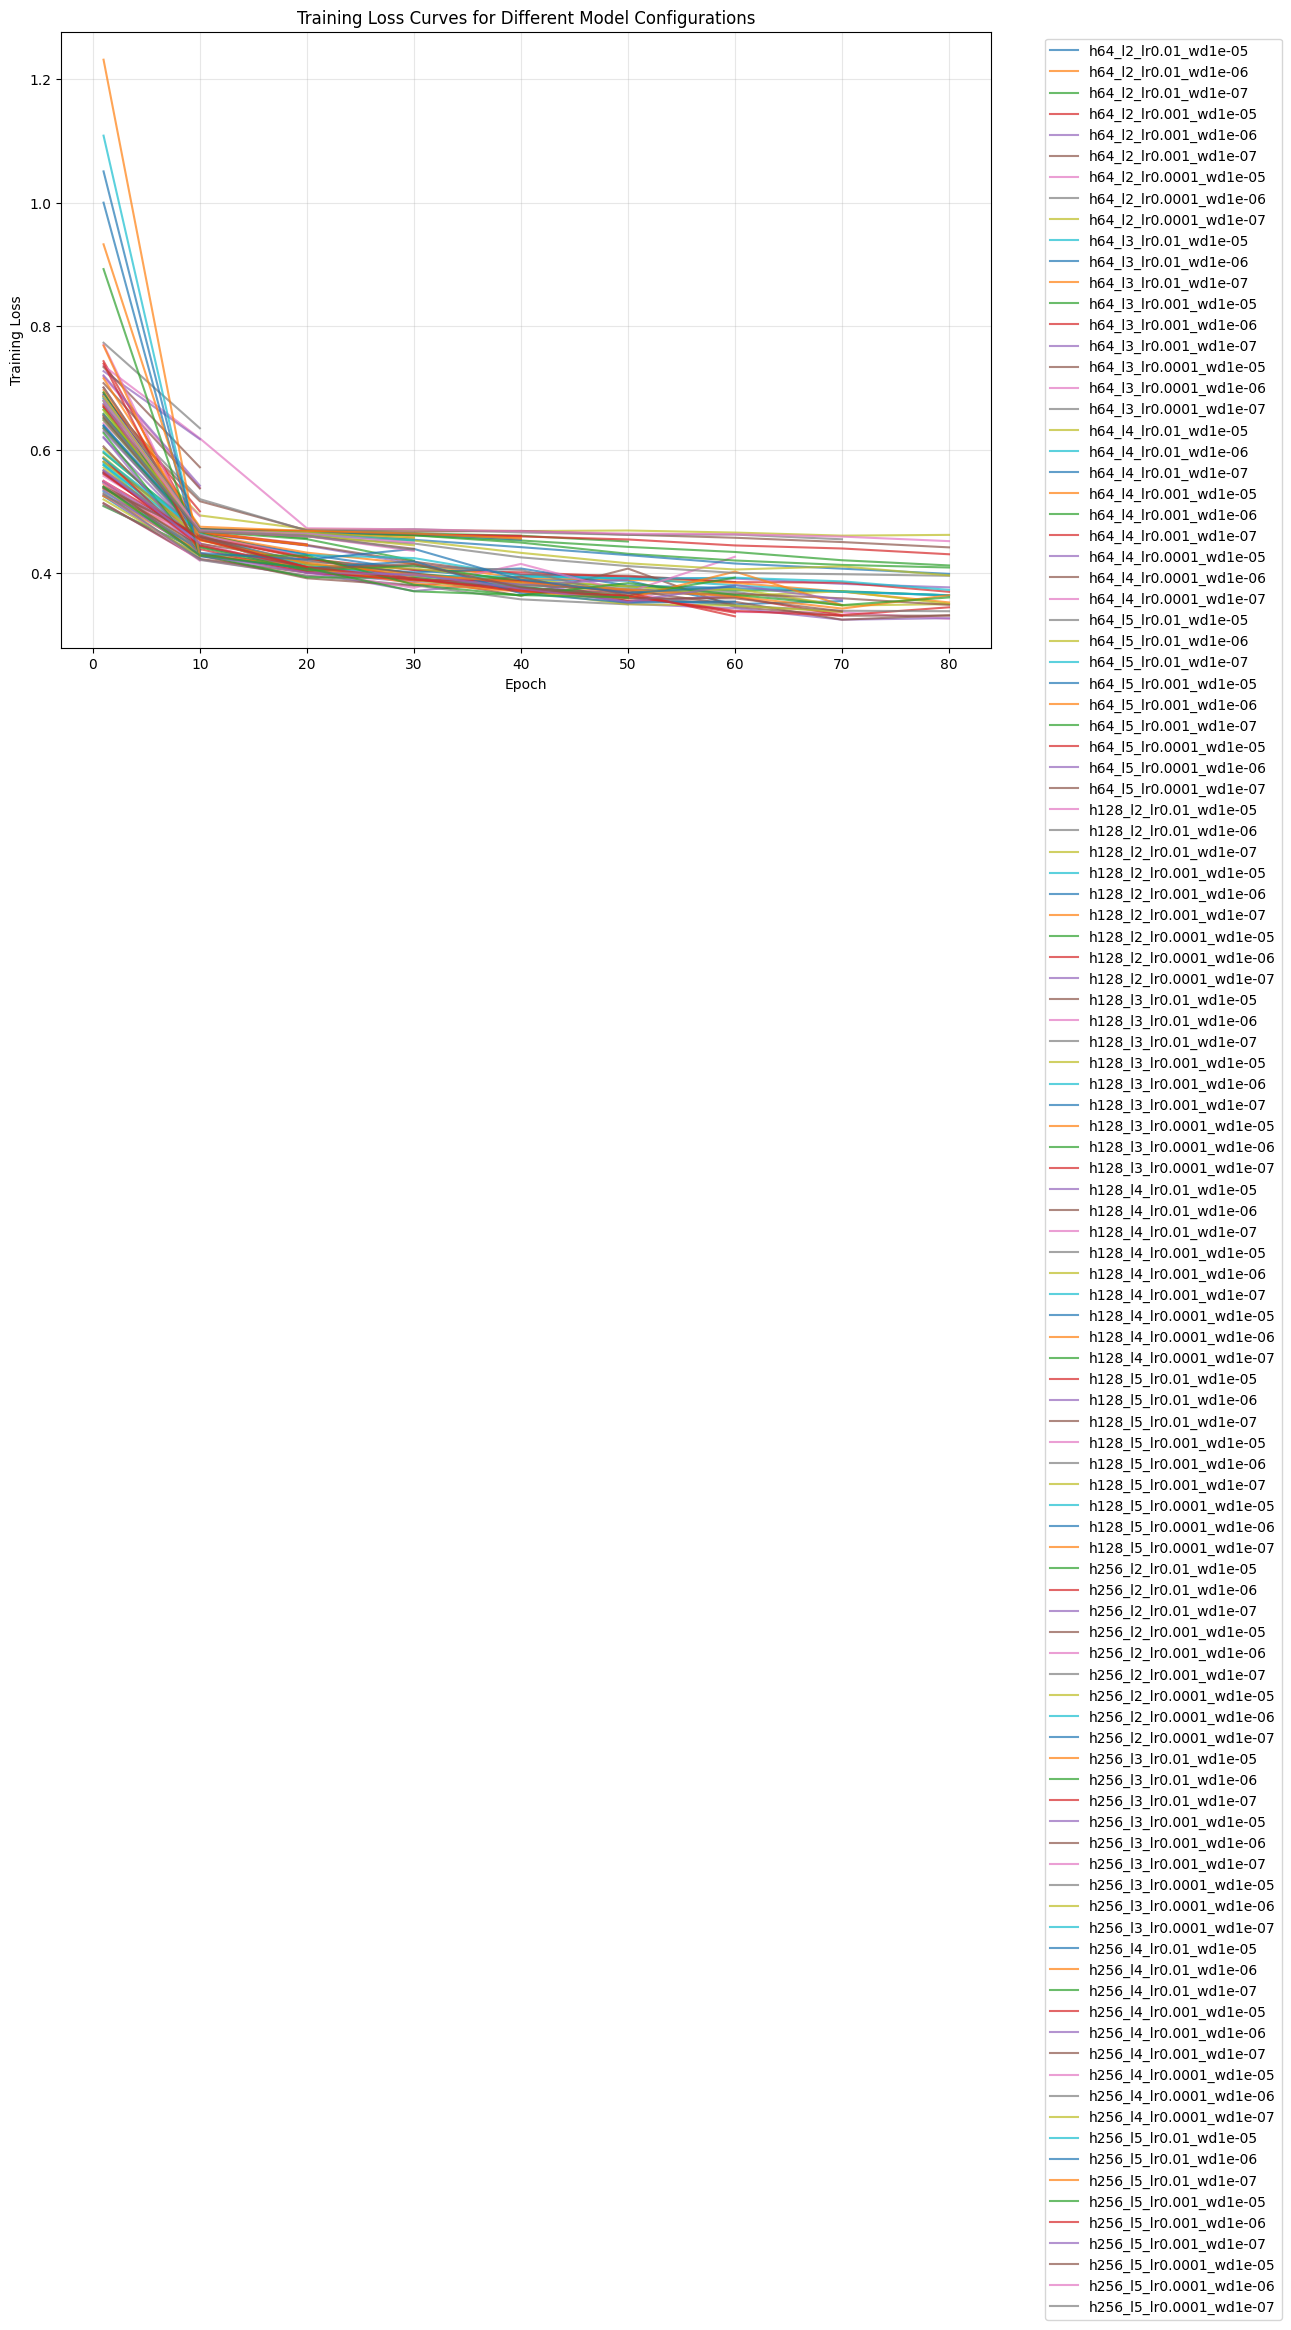

/var/folders/86/621cyyk16gd11mlx6jm2h4c80000gn/T/ipykernel_63051/3341766731.py:43: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


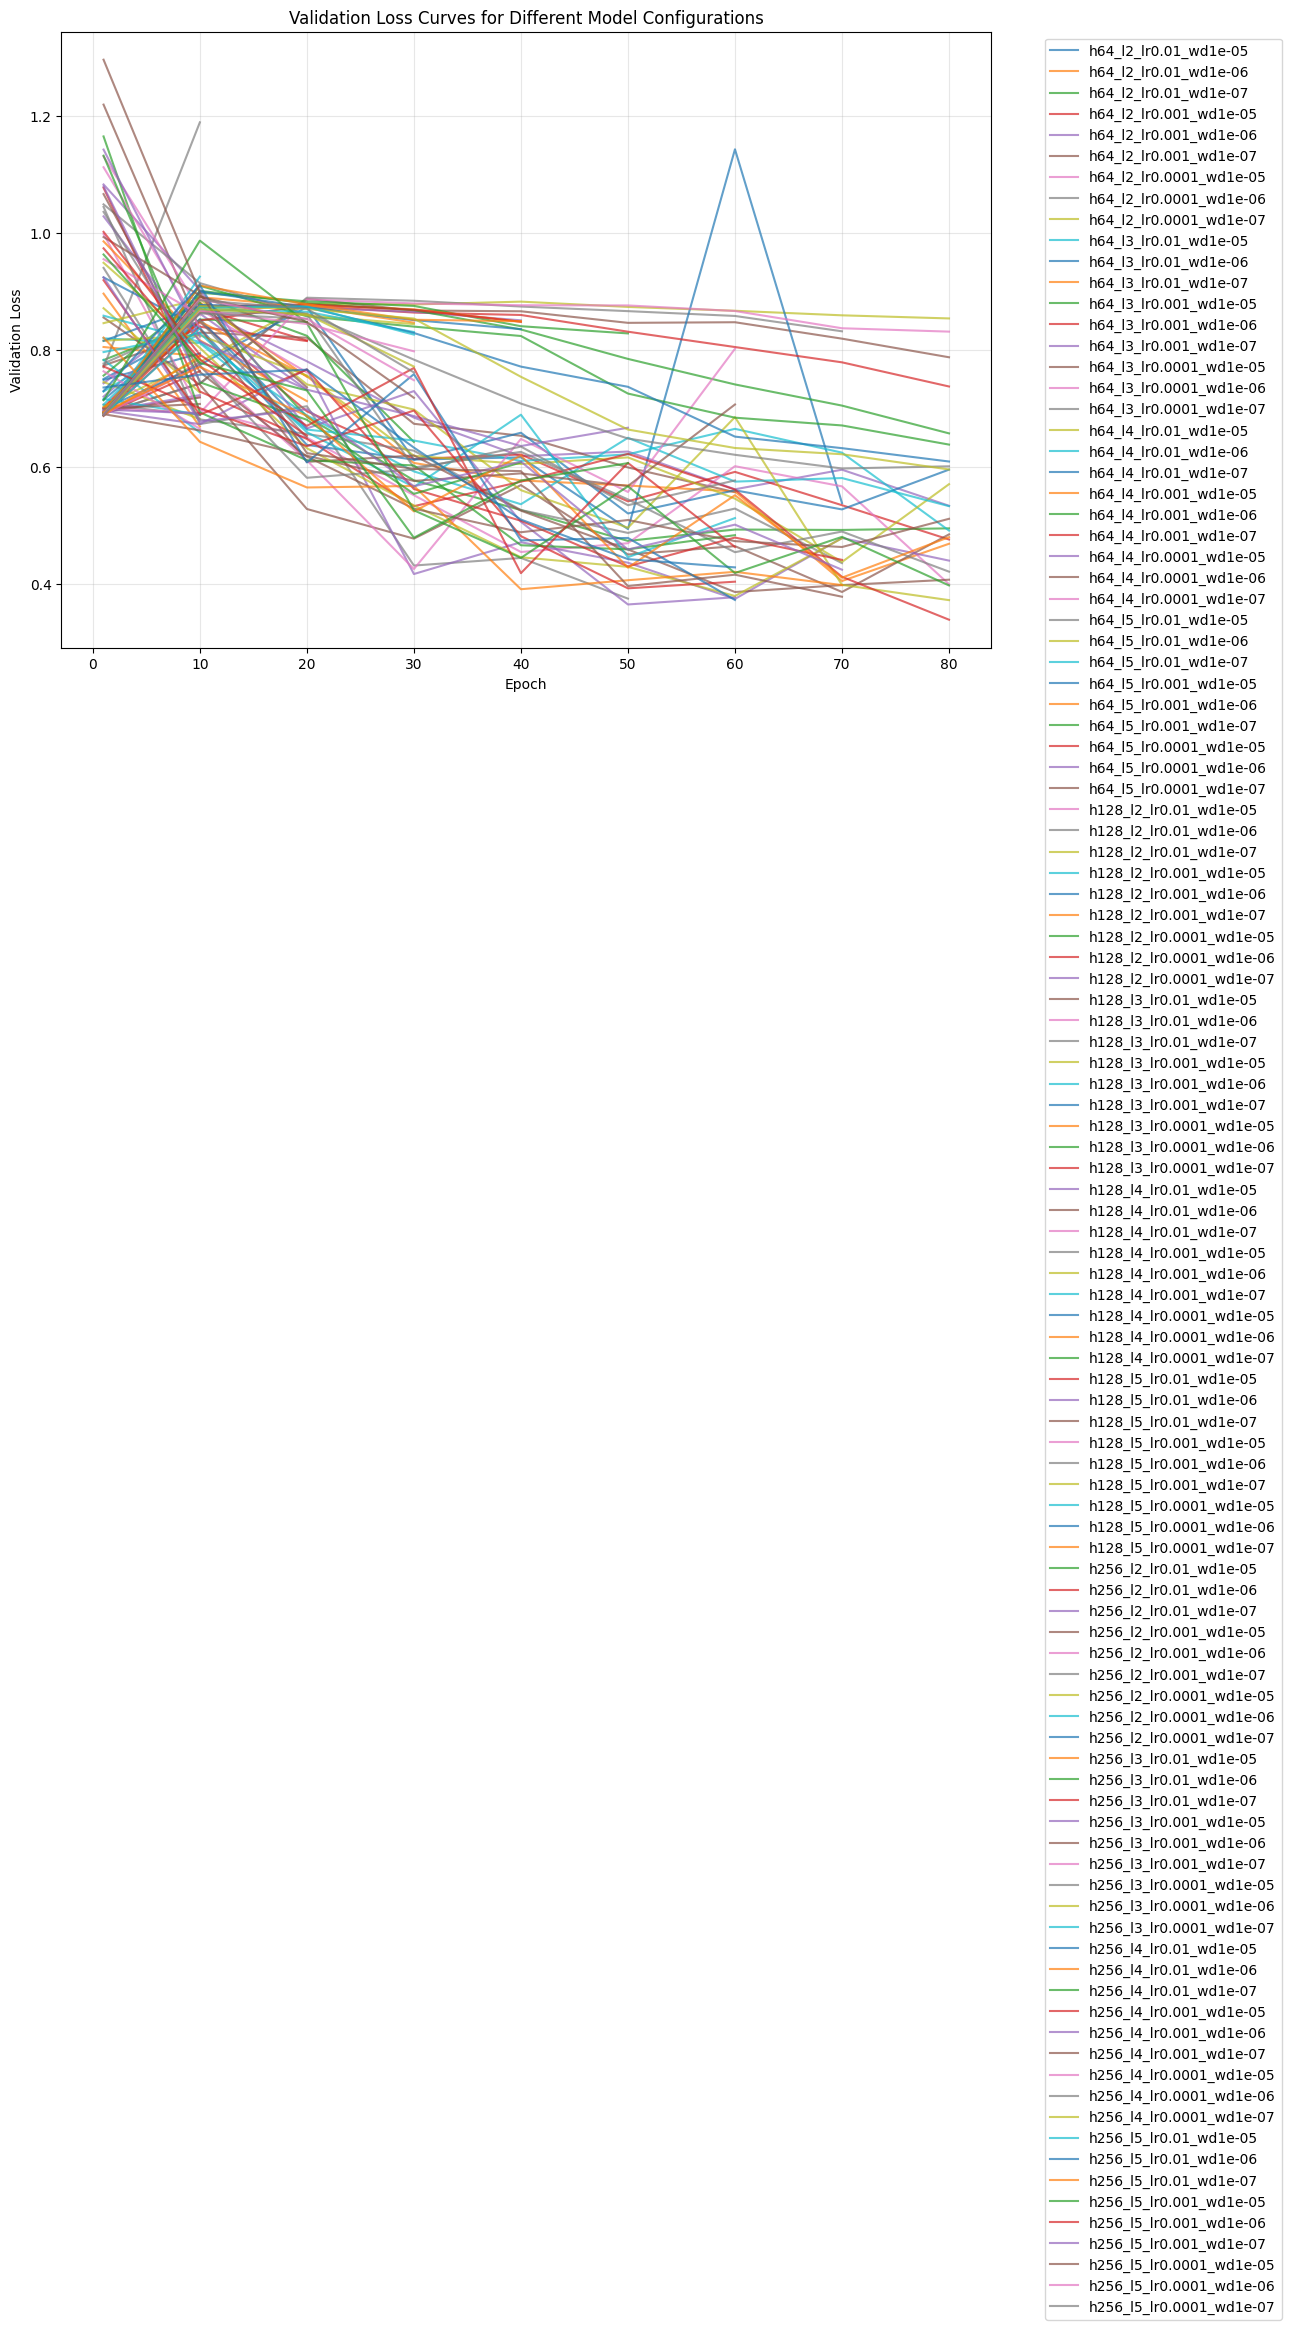

/var/folders/86/621cyyk16gd11mlx6jm2h4c80000gn/T/ipykernel_63051/3341766731.py:59: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


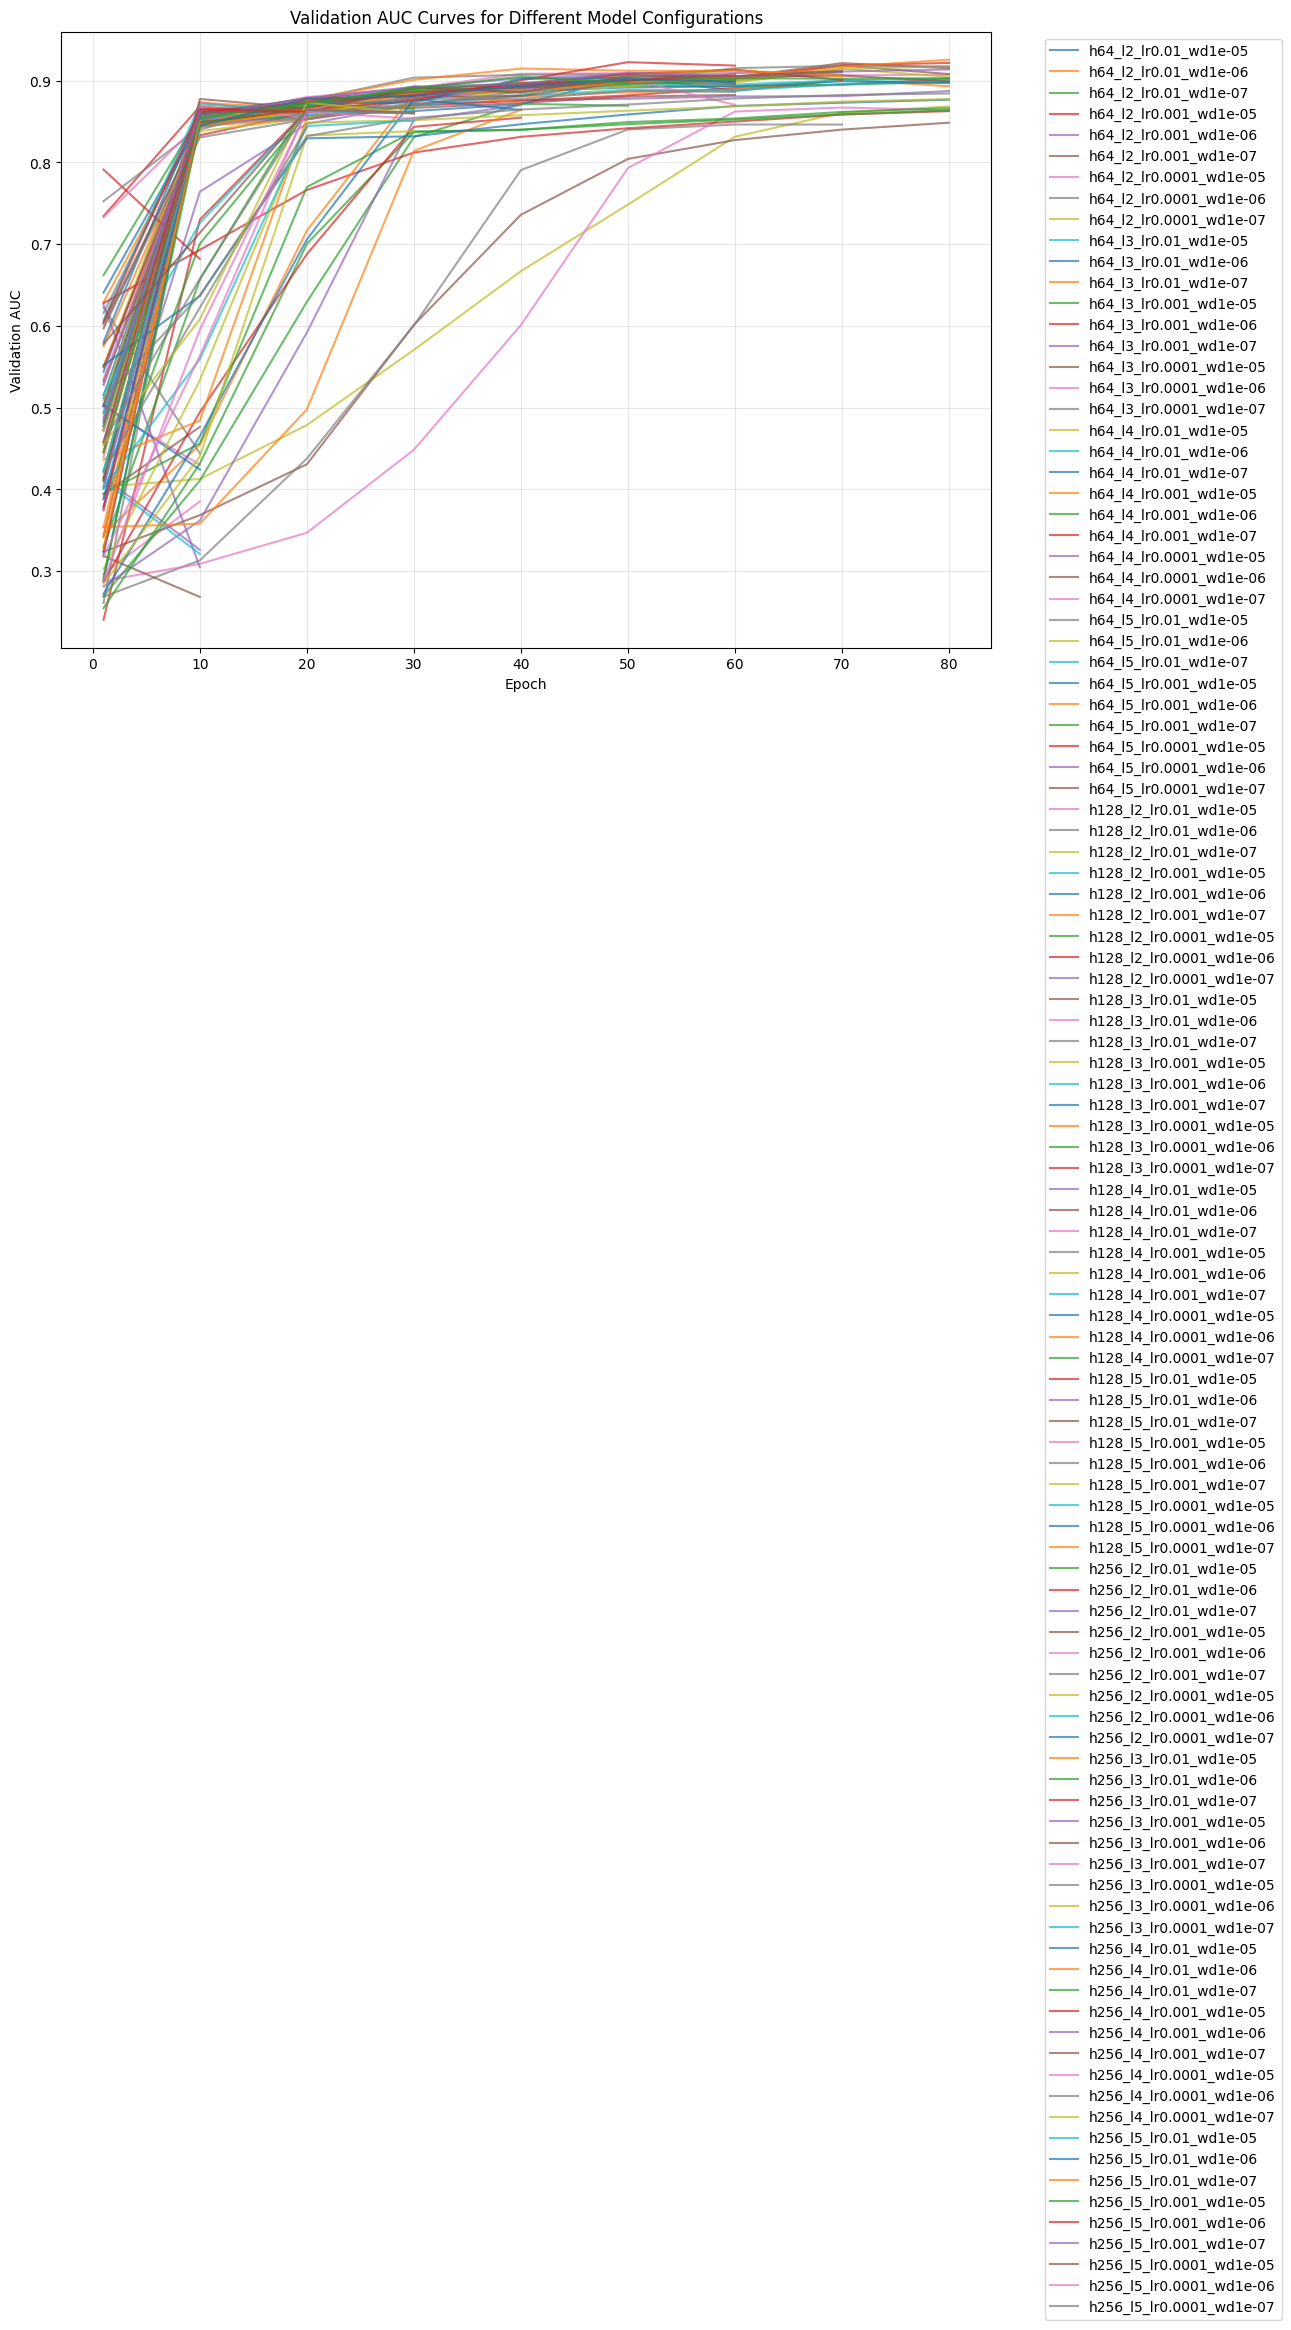

Plotted 108 different model configurations


In [9]:
# Plotting code to visualize loss curves for each model configuration
import matplotlib.pyplot as plt
import seaborn as sns

# Load the epoch data
epoch_df = pd.read_csv('grid_epoch_data.csv')

# Create a unique identifier for each model configuration
epoch_df['model_id'] = (epoch_df['hidden_channels'].astype(str) + '_' + 
                       epoch_df['num_layers'].astype(str) + '_' + 
                       epoch_df['learning_rate'].astype(str) + '_' + 
                       epoch_df['weight_decay'].astype(str))

# Plot training loss curves
plt.figure(figsize=(12, 8))
for model_id in epoch_df['model_id'].unique():
    model_data = epoch_df[epoch_df['model_id'] == model_id]
    config = model_data.iloc[0]
    label = f"h{config['hidden_channels']}_l{config['num_layers']}_lr{config['learning_rate']}_wd{config['weight_decay']}"
    plt.plot(model_data['epoch'], model_data['train_loss'], label=label, alpha=0.7)

plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Training Loss Curves for Different Model Configurations')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot validation loss curves
plt.figure(figsize=(12, 8))
for model_id in epoch_df['model_id'].unique():
    model_data = epoch_df[epoch_df['model_id'] == model_id]
    config = model_data.iloc[0]
    label = f"h{config['hidden_channels']}_l{config['num_layers']}_lr{config['learning_rate']}_wd{config['weight_decay']}"
    plt.plot(model_data['epoch'], model_data['val_loss'], label=label, alpha=0.7)

plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('Validation Loss Curves for Different Model Configurations')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot validation AUC curves
plt.figure(figsize=(12, 8))
for model_id in epoch_df['model_id'].unique():
    model_data = epoch_df[epoch_df['model_id'] == model_id]
    config = model_data.iloc[0]
    label = f"h{config['hidden_channels']}_l{config['num_layers']}_lr{config['learning_rate']}_wd{config['weight_decay']}"
    plt.plot(model_data['epoch'], model_data['val_auc'], label=label, alpha=0.7)

plt.xlabel('Epoch')
plt.ylabel('Validation AUC')
plt.title('Validation AUC Curves for Different Model Configurations')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Plotted {len(epoch_df['model_id'].unique())} different model configurations")


In [9]:
import optuna
import optuna.visualization as vis
from loadMoleculeData import load_datasets
from model_configs import ModelConfig

class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels=128, num_layers=3, dropout=0.2):
        super().__init__()
        self.convs = nn.ModuleList()
        self.convs.append(GCNConv(in_channels, hidden_channels))
        for _ in range(num_layers-2):
            self.convs.append(GCNConv(hidden_channels, hidden_channels))
        self.convs.append(GCNConv(hidden_channels, hidden_channels))

        self.dropout = dropout
        self.lin = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels),
            nn.ReLU(),
            nn.Dropout(self.dropout),
            nn.Linear(hidden_channels, 1)
        )

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = x.float()
        for conv in self.convs:
            x = conv(x, edge_index)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
            g = global_mean_pool(x, batch)

        return self.lin(g).view(-1)

def objective(trial, dataset_name='BBBP'):
    """Objective function for Optuna - much simpler than custom implementation."""
    
    # Load dataset
    datasets = load_datasets([dataset_name])
    dataset = datasets[0]
    train_loader = DataLoader(dataset['train_set'], batch_size=256, shuffle=True)
    val_loader = DataLoader(dataset['val_set'], batch_size=256, shuffle=False)
    
    # Define search space (your exact parameters)
    hidden_channels = trial.suggest_categorical('hidden_channels', [64, 128, 256])
    num_layers = trial.suggest_categorical('num_layers', [2, 3, 4, 5])
    dropout = trial.suggest_categorical('dropout', [0.1])
    learning_rate = trial.suggest_categorical('learning_rate', [1e-2, 1e-3])
    weight_decay = trial.suggest_categorical('weight_decay', [1e-5, 1e-7])
    
    # Create model
    original_dataset = dataset['train_set'].dataset
    model = GCN(in_channels=original_dataset.num_features, 
               config=ModelConfig(
                   hidden_channels=hidden_channels,
                   num_layers=num_layers,
                   dropout=dropout,
                   learning_rate=learning_rate,
                   weight_decay=weight_decay
               ))
    model = model.to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    criterion = nn.BCEWithLogitsLoss()
    
    # Training with early stopping
    best_val_auc = -1.0
    for epoch in range(1, 81):  # 80 epochs max
        train_loss, train_auc = do_epoch(train_loader, training=True, model=model, 
                                       optimizer=optimizer, criterion=criterion)
        val_loss, val_auc = do_epoch(val_loader, training=False, model=model, criterion=criterion)
        
        if val_auc > best_val_auc:
            best_val_auc = val_auc
        
        # Report intermediate result for pruning
        trial.report(val_auc, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()
    
    return best_val_auc


study = optuna.create_study(direction='maximize')
study.optimize(lambda trial: objective(trial, 'BBBP'), n_trials=48)  # 48 = 3*4*1*2*2

print(f"Best parameters: {study.best_params}")
print(f"Best validation AUC: {study.best_value:.4f}")


[I 2025-10-22 17:42:58,584] A new study created in memory with name: no-name-6fcd06f7-aa18-4eab-8986-5bf2bd02e022
[17:42:58] WARNING: not removing hydrogen atom without neighbors
[17:42:58] WARNING: not removing hydrogen atom without neighbors
[17:42:58] WARNING: not removing hydrogen atom without neighbors
[17:42:58] WARNING: not removing hydrogen atom without neighbors
[17:42:58] WARNING: not removing hydrogen atom without neighbors
[17:42:58] WARNING: not removing hydrogen atom without neighbors
[17:42:58] WARNING: not removing hydrogen atom without neighbors
[17:42:58] WARNING: not removing hydrogen atom without neighbors
[17:42:58] WARNING: not removing hydrogen atom without neighbors
[17:42:58] WARNING: not removing hydrogen atom without neighbors
[17:42:58] WARNING: not removing hydrogen atom without neighbors
[17:42:58] WARNING: not removing hydrogen atom without neighbors
[17:42:58] WARNING: not removing hydrogen atom without neighbors
[17:42:58] WARNING: not removing hydrogen

TypeError: GCN.__init__() got an unexpected keyword argument 'config'